Backtesting | Research

**Objetivo**: Probar los modulos de Backtesting



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from src.backtesting import (
    BacktestConfig,
    Backtester,
    MeanVarianceStrategy,
    PostModernStrategy,
)

from src.optimization import (
    OptimizationConfig,
    MinimumVarianceConfig,
    MinimumSemivarianceConfig,
)


In [69]:
pd.options.display.float_format = "{:,.6f}".format

In [59]:
tickers = ["LLY", "NVDA", "MSFT", "KXI"]
start_op = '2019-01-01'
start_back = '2023-01-01'
end = '2026-03-20'
V0 = 100_000
free_rate = 0.035

In [60]:
config = BacktestConfig(
    tickers=tickers,
    initial_capital=V0,
    optimization_start=start_op,
    backtest_start=start_back,
    end=end
)

Strategy1 = Backtester(
    config=config
)

strategies = [
    MeanVarianceStrategy(
        objective="minimum_variance",
        config=MinimumVarianceConfig(),
        name="Min Var"
    ),
    
    PostModernStrategy(
        objective="minimum_semivariance",
        config=MinimumSemivarianceConfig(threshold=0.0),
        name="Min Semivar"
    )
]

In [61]:
result = Strategy1.run(strategies=strategies)

In [62]:
result.evolution

,Min Var,Min Semivar
Date,,
2023-01-04,100628.887219,100497.032040
2023-01-05,99778.129406,99612.055689
2023-01-06,102002.581216,101705.734939
2023-01-09,101481.829946,100823.769781
2023-01-10,101366.928346,100819.510747
...,...,...
2026-03-13,129080.221409,143324.052320
2026-03-16,129968.059326,144264.095721
2026-03-17,129020.506690,142347.629655


In [63]:
result.prices_optimization

Ticker,LLY,NVDA,MSFT,KXI
Date,,,,
2019-01-02,104.341858,3.376983,94.397156,38.773102
2019-01-03,101.099335,3.172956,90.924492,38.663094
2019-01-04,104.142052,3.376240,95.153282,39.517769
2019-01-07,104.705162,3.554980,95.274651,39.390831
2019-01-08,105.667915,3.466478,95.965431,39.526230
...,...,...,...,...
2022-12-23,358.666077,15.189970,232.624542,55.655163
2022-12-27,355.721832,14.106116,230.899826,55.803349
2022-12-28,356.053284,14.021205,228.531952,55.155010


In [70]:
result.metrics

,Min Var,Min Semivar
Rend Esperado,0.076642,0.108725
Rend Efectivo,0.251449,0.383364
Volatilidad,0.112575,0.118336
Sharpe,0.680809,0.918787
Downside,0.065759,0.068948
Upside,0.068709,0.073264
Omega,1.044864,1.062598


In [71]:
result.strategy_results["Min Semivar"].weights_by_ticker

LLY    0.146839
NVDA   0.000000
MSFT   0.000000
KXI    0.853161
Name: weight, dtype: float64

In [72]:
result.strategy_results["Min Var"].weights_by_ticker

LLY    0.035991
NVDA   0.000000
MSFT   0.000000
KXI    0.964009
Name: weight, dtype: float64

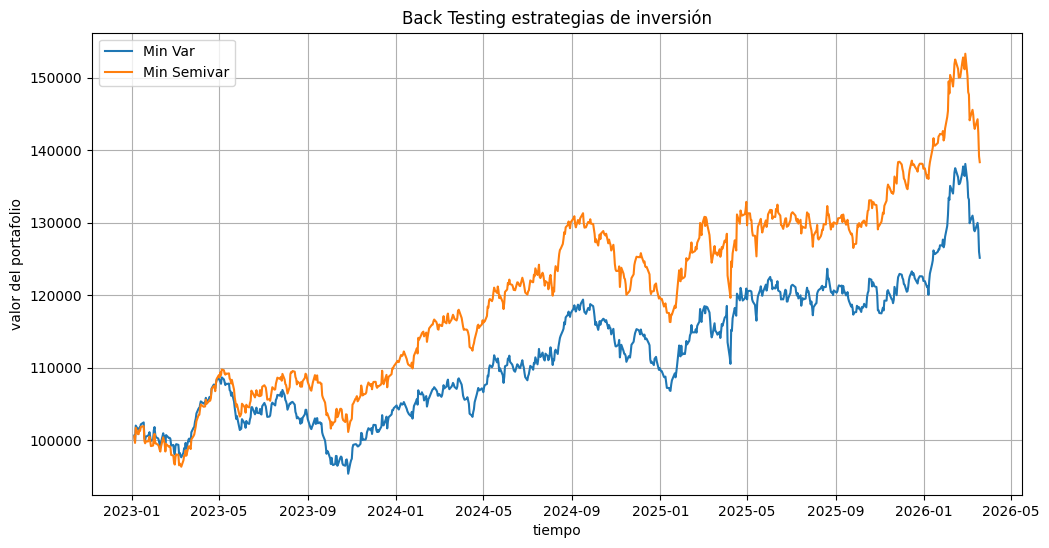

In [67]:
# Graficar la evolucion para ambos portafolios
plt.figure(figsize=(12, 6))
plt.plot(result.evolution, label=result.evolution.columns)
plt.legend()

plt.xlabel("tiempo")
plt.ylabel("valor del portafolio")

plt.title("Back Testing estrategias de inversión")

plt.grid()

plt.show()